# K Nearest Neighbors Implementartion using MapReduce in Spark

In [1]:
from pyspark import SparkConf
from pyspark.sql import SparkSession

spark = SparkSession.builder.master("local[*]").appName("MR-kNN").getOrCreate()
sc = spark.sparkContext

import matplotlib.pyplot as plt

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/04/02 20:34:55 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
26/04/02 20:34:55 WARN Utils: Service 'SparkUI' could not bind on port 4040. Attempting port 4041.


## RDD implementation

### Load Datasets

Source: Robert Cattral (cattral@gmail.com), Franz Oppacher (oppacher@scs.carleton.ca)
	Carleton University, Department of Computer Science
	Intelligent Systems Research Unit
	1125 Colonel By Drive, Ottawa, Ontario, Canada, K1S5B6; Jan 2007

In [2]:
train_full_rdd = sc.textFile("Dataset/poker+hand/poker-hand-training-true.data")
test_rdd  = sc.textFile("Dataset/poker+hand/poker-hand-testing.data")

- Each record is an example of a hand consisting of five playing
     cards drawn from a standard deck of 52. Each card is described
     using two attributes (suit and rank), for a total of 10 predictive
     attributes. There is one Class attribute that describes the
     Poker Hand. The order of cards is important, which is why there
     are 480 possible Royal Flush hands as compared to 4 (one for each
     suit explained in more detail below).

- Number of Instances: 25010 training, 1,000,000 testing

- Number of Attributes: 10 predictive attributes, 1 goal attribute

Attribute Information:
   1) S1 Suit of card #1
      Ordinal (1-4) representing {Hearts, Spades, Diamonds, Clubs}

   2) C1 Rank of card #1
      Numerical (1-13) representing (Ace, 2, 3, ... , Queen, King)

   3) S2 Suit of card #2
      Ordinal (1-4) representing {Hearts, Spades, Diamonds, Clubs}

   4) C2 Rank of card #2
      Numerical (1-13) representing (Ace, 2, 3, ... , Queen, King)

   5) S3 Suit of card #3
      Ordinal (1-4) representing {Hearts, Spades, Diamonds, Clubs}

   6) C3 Rank of card #3
      Numerical (1-13) representing (Ace, 2, 3, ... , Queen, King)

   7) S4 Suit of card #4
      Ordinal (1-4) representing {Hearts, Spades, Diamonds, Clubs}

   8) C4 Rank of card #4
      Numerical (1-13) representing (Ace, 2, 3, ... , Queen, King)

   9) S5 Suit of card #5
      Ordinal (1-4) representing {Hearts, Spades, Diamonds, Clubs}

   10) C5 Rank of card 5
      Numerical (1-13) representing (Ace, 2, 3, ... , Queen, King)

   11) CLASS Poker Hand
      Ordinal (0-9)
      
      0: Nothing in hand; not a recognized poker hand 
      1: One pair; one pair of equal ranks within five cards
      2: Two pairs; two pairs of equal ranks within five cards
      3: Three of a kind; three equal ranks within five cards
      4: Straight; five cards, sequentially ranked with no gaps
      5: Flush; five cards with the same suit
      6: Full house; pair + different rank three of a kind
      7: Four of a kind; four equal ranks within five cards
      8: Straight flush; straight + flush
      9: Royal flush; {Ace, King, Queen, Jack, Ten} + flush

In [3]:
train_full_rdd.take(10)

['1,10,1,11,1,13,1,12,1,1,9',
 '2,11,2,13,2,10,2,12,2,1,9',
 '3,12,3,11,3,13,3,10,3,1,9',
 '4,10,4,11,4,1,4,13,4,12,9',
 '4,1,4,13,4,12,4,11,4,10,9',
 '1,2,1,4,1,5,1,3,1,6,8',
 '1,9,1,12,1,10,1,11,1,13,8',
 '2,1,2,2,2,3,2,4,2,5,8',
 '3,5,3,6,3,9,3,7,3,8,8',
 '4,1,4,4,4,2,4,3,4,5,8']

For example, in this case, the first line '1,10,1,11,1,13,1,12,1,1,9' represents the following:
| Column | Value | Interpretation |
|------|------|------|
| S1| 1| Card 1 suit: Hearts |
| C1 | 10 | Card 1 rank: 10 |
| S2| 1| Card 2 suit: Hearts |
| C2 | 11 | Card 2 rank: Jack |
| S3| 1| Card 3 suit: Hearts |
| C3 | 13 | Card 3 rank: King |
| S4| 1| Card 4 suit: Hearts |
| C4 | 12 | Card 4 rank: Queen |
| S5| 1| Card 4 suit: Hearts |
| C5 | 1 | Card 5 rank: Ace |
| **Label**| 9| **Royal Flush** |

Based on this interpretation, we dacide to make the following arragement: we represent each like in a (key, value) tuple where the key is the predictive attributes and the value is the goal attribute.

In our example, we would have: k = 1,10,1,11,1,13,1,12,1,1 and v = 9.

In [4]:
train_full_rdd = (train_full_rdd.map(lambda line: line.split(","))
               .map(lambda x: (list(map(int, x[:10])), int(x[10])))
                    )
train_full_rdd.take(10)


[([1, 10, 1, 11, 1, 13, 1, 12, 1, 1], 9),
 ([2, 11, 2, 13, 2, 10, 2, 12, 2, 1], 9),
 ([3, 12, 3, 11, 3, 13, 3, 10, 3, 1], 9),
 ([4, 10, 4, 11, 4, 1, 4, 13, 4, 12], 9),
 ([4, 1, 4, 13, 4, 12, 4, 11, 4, 10], 9),
 ([1, 2, 1, 4, 1, 5, 1, 3, 1, 6], 8),
 ([1, 9, 1, 12, 1, 10, 1, 11, 1, 13], 8),
 ([2, 1, 2, 2, 2, 3, 2, 4, 2, 5], 8),
 ([3, 5, 3, 6, 3, 9, 3, 7, 3, 8], 8),
 ([4, 1, 4, 4, 4, 2, 4, 3, 4, 5], 8)]

In [5]:
train_rdd = train_full_rdd.sample(withReplacement=False, fraction=0.1, seed=42)
print(f"Sampled train size: {train_rdd.count()}")

Sampled train size: 2419


In [6]:
test_rdd = (test_rdd.map(lambda line: line.split(","))
               .map(lambda x: (list(map(int, x[:10])), int(x[10])))
                    )
test_rdd.take(10)

[([1, 1, 1, 13, 2, 4, 2, 3, 1, 12], 0),
 ([3, 12, 3, 2, 3, 11, 4, 5, 2, 5], 1),
 ([1, 9, 4, 6, 1, 4, 3, 2, 3, 9], 1),
 ([1, 4, 3, 13, 2, 13, 2, 1, 3, 6], 1),
 ([3, 10, 2, 7, 1, 2, 2, 11, 4, 9], 0),
 ([1, 3, 4, 5, 3, 4, 1, 12, 4, 6], 0),
 ([2, 6, 4, 11, 2, 3, 4, 9, 1, 7], 0),
 ([3, 2, 4, 9, 3, 7, 4, 3, 4, 5], 0),
 ([4, 4, 3, 13, 1, 8, 3, 9, 3, 10], 0),
 ([1, 9, 3, 8, 4, 4, 1, 7, 3, 5], 0)]

In [7]:
test_rdd = sc.parallelize(test_rdd.take(5000))
print(f"Sampled test size: {test_rdd.count()}")

Sampled test size: 5000


### Map Phase

In [8]:
## Partitioning: only the train dataset is partitioned
m = 16 # number of parttions
train_part = train_rdd.repartition(m)


In [9]:
test_broad = sc.broadcast(test_rdd.collect())

In [10]:
import math
# eucledian distance
def euclidean_distance(a, b):
    return math.sqrt(sum((x - y) ** 2 for x, y in zip(a, b)))

In [11]:
k=5
def map_knn(partition_index, partition_iter):
    tr_j = list(partition_iter)           # TR_j
    ts   = test_broad.value           # full test set

    # CD_j[i] = k nearest (class, dist) pairs
    cd_j = []
    for test_features, _ in ts:
        distances = [(label, euclidean_distance(test_features, tr_features))
                     for tr_features, label in tr_j]
        # sort scendingly
        top_k = sorted(distances, key=lambda x: x[1])[:k]
        cd_j.append(top_k)

    yield (partition_index, cd_j)

cd_rdd = train_part.mapPartitionsWithIndex(map_knn)

### Reduce Phase

In [12]:
from collections import Counter

n_test = test_rdd.count()

# one reducer
single_key_rdd = cd_rdd.map(lambda x: (0, x[1]))

# reducer initialized with inf distances (n_test × k matrix)
def init_cd_reducer():
    return [[(0, float('inf'))] * k for _ in range(n_test)]

# reduce (algorithm 2): merge CD_j into reducer
# Both matrices are sorted ascending: O(k) merge per test
def reduce_op(cd_reducer, cd_j):
    for i in range(n_test):
        merged = []
        a, b   = 0, 0
        while len(merged) < k:
            dist_r = cd_reducer[i][a][1] if a < k else float('inf')
            dist_j = cd_j[i][b][1]       if b < k else float('inf')
            if dist_r <= dist_j:
                merged.append(cd_reducer[i][a]); a += 1
            else:
                merged.append(cd_j[i][b]);       b += 1
        cd_reducer[i] = merged
    return cd_reducer


cd_reducer_rdd = single_key_rdd.aggregateByKey(
    init_cd_reducer(),
    reduce_op,           # reduce
    reduce_op            # combine
)

# cleanup (algorithm 3): majority vote -> emit (i, predicted_class)
def cleanup(item):
    _, cd_reducer = item
    for i, neighbors in enumerate(cd_reducer):
        classes = [c for c, _ in neighbors]
        pred = Counter(classes).most_common(1)[0][0]
        yield (i, pred)

predictions_rdd = cd_reducer_rdd.flatMap(cleanup)
# (test_idx, predicted_class)

In [13]:
predictions_rdd.take(10)

[(0, 0),
 (1, 0),
 (2, 0),
 (3, 0),
 (4, 1),
 (5, 0),
 (6, 1),
 (7, 0),
 (8, 1),
 (9, 2)]

In [14]:
# Distribution of predicted classes
print("\nPredicted class distribution:")
pred_dist = (predictions_rdd
    .map(lambda x: (x[1], 1))
    .reduceByKey(lambda a, b: a + b)
    .sortByKey()
    .collect()
)
for cls, count in pred_dist:
    print(f"  Class {cls}: {count}")

# Accuracy
ground_truth = (test_rdd
    .zipWithIndex()
    .map(lambda x: (x[1], x[0][1]))
)

accuracy = (predictions_rdd
    .join(ground_truth)
    .map(lambda x: int(x[1][0] == x[1][1]))
    .mean()
)
print(f"\nAccuracy (k={k}, m={m}): {accuracy:.4f}")


Predicted class distribution:
  Class 0: 2840
  Class 1: 2067
  Class 2: 64
  Class 3: 26
  Class 4: 1
  Class 5: 1
  Class 6: 1

Accuracy (k=5, m=16): 0.5314


### Experimental Analysis

In [15]:
import time
from collections import Counter
import pandas as pd

# Parametric map phase
def make_map_phase(test_broadcast, k):
    def map_phase(partition_index, partition_iter):
        tr_j = list(partition_iter)
        ts   = test_broadcast.value
        cd_j = []
        for ts_features, _ in ts:
            distances = [(label, euclidean_distance(ts_features, tr_features))
                         for tr_features, label in tr_j]
            cd_j.append(sorted(distances, key=lambda x: x[1])[:k])
        yield (partition_index, cd_j)
    return map_phase

# Parametric reduce phase
def init_cd_reducer(n_test, k):
    return [[(0, float('inf'))] * k for _ in range(n_test)]

def make_reduce_op(n_test, k):
    def reduce_op(cd_reducer, cd_j):
        for i in range(n_test):
            merged = []
            a, b   = 0, 0
            len_r  = len(cd_reducer[i])
            len_j  = len(cd_j[i])
            while len(merged) < k:
                dist_r = cd_reducer[i][a][1] if a < len_r else float('inf')
                dist_j = cd_j[i][b][1]       if b < len_j else float('inf')
                if dist_r == float('inf') and dist_j == float('inf'):
                    break
                if dist_r <= dist_j:
                    merged.append(cd_reducer[i][a]); a += 1
                else:
                    merged.append(cd_j[i][b]);       b += 1
            cd_reducer[i] = merged
        return cd_reducer
    return reduce_op



def cleanup(item):
    _, cd_reducer = item
    for i, neighbors in enumerate(cd_reducer):
        yield (i, Counter(c for c, _ in neighbors).most_common(1)[0][0])

# Sequential k-NN (baseline)
def sequential_knn(train_data, test_data, k):
    start = time.time()
    correct = 0
    for ts_features, ts_label in test_data:
        distances = [(label, euclidean_distance(ts_features, tr_features))
                     for tr_features, label in train_data]
        pred = Counter(c for c, _ in sorted(distances, key=lambda x: x[1])[:k]).most_common(1)[0][0]
        correct += (pred == ts_label)
    return correct / len(test_data), time.time() - start

# MR-kNN
def run_mrknn(train_rdd, test_rdd, k, m, n_test, ground_truth_rdd):
    global_start   = time.time()
    test_broadcast = sc.broadcast(test_rdd.collect())
    train_part     = train_rdd.repartition(m)

    map_start = time.time()
    cd_rdd = train_part.mapPartitionsWithIndex(make_map_phase(test_broadcast, k))
    cd_rdd.cache(); cd_rdd.count()
    map_time = time.time() - map_start

    reduce_op    = make_reduce_op(n_test, k)
    reduce_start = time.time()
    predictions_rdd = (cd_rdd
        .map(lambda x: (0, x[1]))
        .aggregateByKey(init_cd_reducer(n_test, k), reduce_op, reduce_op)
        .flatMap(cleanup)
    )
    predictions_rdd.cache(); predictions_rdd.count()
    reduce_time = time.time() - reduce_start

    global_time = time.time() - global_start
    accuracy = (predictions_rdd
        .join(ground_truth_rdd)
        .map(lambda x: int(x[1][0] == x[1][1]))
        .mean()
    )

    cd_rdd.unpersist(); predictions_rdd.unpersist(); test_broadcast.unpersist()
    return accuracy, map_time, reduce_time, global_time


In [16]:
import pandas as pd

# full dataset and fold IDs
full_rdd = train_rdd.union(test_rdd)

# Assign fold 0–4 by index % 5 (deterministic, no shuffle needed)
full_indexed = (full_rdd
    .zipWithIndex()
    .map(lambda x: (x[1] % 5, x[0]))                     # (fold_id, (features, label))
)
full_indexed.cache()

k_values = [1, 3, 5, 7]
m_values = [16, 32, 64, 128, 256]
n_folds  = 5

all_results = []

# 5-Fold Cross-Validation loop
for fold in range(n_folds):
    print(f"\n=== Fold {fold + 1} / {n_folds} ===")

    fold_train_rdd = (full_indexed
        .filter(lambda x, f=fold: x[0] != f)
        .map(lambda x: x[1])
    )
    fold_test_rdd = (full_indexed
        .filter(lambda x, f=fold: x[0] == f)
        .map(lambda x: x[1])
    )

    fold_train_rdd.cache()
    fold_test_rdd.cache()

    n_test       = fold_test_rdd.count()
    train_data   = fold_train_rdd.collect()
    test_data    = fold_test_rdd.collect()

    # Ground truth: (test_idx, true_label)
    ground_truth_rdd = (fold_test_rdd
        .zipWithIndex()
        .map(lambda x: (x[1], x[0][1]))
    ).cache()

    for k in k_values:
        print(f"  k={k}")

        # Sequential reference (m=1)
        seq_acc, seq_time = sequential_knn(train_data, test_data, k)
        all_results.append({
            "fold": fold + 1, "k": k, "m": 1, "type": "sequential",
            "accuracy":    round(seq_acc,  4),
            "map_time":    None,
            "reduce_time": None,
            "global_time": round(seq_time, 3),
            "speedup":     1.0
        })

        for m in m_values:
            print(f"    m={m}")
            acc, map_t, red_t, glob_t = run_mrknn(
                fold_train_rdd, fold_test_rdd, k, m, n_test, ground_truth_rdd
            )
            all_results.append({
                "fold": fold + 1, "k": k, "m": m, "type": "MR-kNN",
                "accuracy":    round(acc,    4),
                "map_time":    round(map_t,  3),
                "reduce_time": round(red_t,  3),
                "global_time": round(glob_t, 3),
                "speedup":     round(seq_time / glob_t, 3)
            })

    ground_truth_rdd.unpersist()
    fold_train_rdd.unpersist()
    fold_test_rdd.unpersist()

full_indexed.unpersist()

# Results averaged over 5 folds
df = pd.DataFrame(all_results)

avg_df = (df
    .groupby(["k", "m", "type"])
    .agg(
        accuracy    =("accuracy",    "mean"),
        map_time    =("map_time",    "mean"),
        reduce_time =("reduce_time", "mean"),
        global_time =("global_time", "mean"),
        speedup     =("speedup",     "mean")
    )
    .round(4)
    .reset_index()
)

print("\n Averaged over 5 folds")
print(avg_df.to_string(index=False))



=== Fold 1 / 5 ===
  k=1
    m=16


    m=32


    m=64


    m=128


    m=256


...

    m=32


    m=64


    m=128


    m=256



 Averaged over 5 folds
 k   m       type  accuracy  map_time  reduce_time  global_time  speedup
 1   1 sequential    0.5006       NaN          NaN       9.7850   1.0000
 1  16     MR-kNN    0.5009    1.4442       0.1778       1.6388   5.9746
 1  32     MR-kNN    0.4998    1.4154       0.3128       1.7572   5.5708
 1  64     MR-kNN    0.4974    1.5118       0.6256       2.1650   4.5208
 1 128     MR-kNN    0.4992    1.7084       1.2108       2.9482   3.3260
 1 256     MR-kNN    0.4991    2.1078       2.4842       4.6198   2.1206
 3   1 sequential    0.5199       NaN          NaN       9.7988   1.0000
 3  16     MR-kNN    0.5198    1.4260       0.2184       1.6596   5.9070
 3  32     MR-kNN    0.5181    1.4354       0.3460       1.8144   5.4026
 3  64     MR-kNN    0.5218    1.5298       0.7028       2.2584   4.3386
 3 128     MR-kNN    0.5232    1.7110       1.3706       3.1126   3.1490
 3 256     MR-kNN    0.5220    2.1016       2.7334       4.8638   2.0146
 5   1 sequential    0.5436

In [17]:
FRACTIONS = [0.1, 0.25, 0.5, 0.75, 1.0]
K_VALUES  = [1, 3, 5, 7]
N_PARTS   = 16


n_test_scal = 5000

ground_truth_scal = (test_rdd
    .zipWithIndex()
    .map(lambda x: (x[1], x[0][1]))
).cache()

scal_results = []
total_runs   = len(K_VALUES) * len(FRACTIONS)
run          = 0

for k_val in K_VALUES:
    for frac in FRACTIONS:
        run += 1
        # vary training fractions
        train_sample = train_full_rdd.sample(False, frac, seed=42)
        n_train      = train_sample.count()
        print(f"[{run}/{total_runs}] k={k_val} | frac={frac} | n_train={n_train}...")

        acc, map_t, red_t, glob_t = run_mrknn(
            train_sample, test_rdd, k_val, N_PARTS, n_test_scal, ground_truth_scal
        )
        scal_results.append({
            "k"           : k_val,
            "fraction"    : frac,
            "n_train"     : n_train,
            "MapTime(s)"  : round(map_t,  2),
            "RedTime(s)"  : round(red_t,  2),
            "TotalTime(s)": round(glob_t, 2),
            "Accuracy"    : round(acc,    4),
        })
        print(f" MapT={map_t:.2f}s | RedT={red_t:.2f}s | Acc={acc:.4f}")

ground_truth_scal.unpersist()

scal_df = pd.DataFrame(scal_results)
print("\n Scalability Results")
print(scal_df.to_string(index=False))


# Save results
scal_df.to_csv("k_frac_results.csv", index=False)
print("\nSaved to k_frac_results.csv")

[1/20] k=1 | frac=0.1 | n_train=2419...


 MapT=1.64s | RedT=0.26s | Acc=0.4830
[2/20] k=1 | frac=0.25 | n_train=6152...


 MapT=3.97s | RedT=0.25s | Acc=0.4942
[3/20] k=1 | frac=0.5 | n_train=12473...


 MapT=7.67s | RedT=0.27s | Acc=0.5068
[4/20] k=1 | frac=0.75 | n_train=18805...


 MapT=11.53s | RedT=0.27s | Acc=0.5004
[5/20] k=1 | frac=1.0 | n_train=25010...


...

 MapT=1.68s | RedT=0.55s | Acc=0.5286
[17/20] k=7 | frac=0.25 | n_train=6152...


 MapT=3.98s | RedT=0.51s | Acc=0.5460
[18/20] k=7 | frac=0.5 | n_train=12473...


 MapT=7.62s | RedT=0.50s | Acc=0.5576
[19/20] k=7 | frac=0.75 | n_train=18805...


 MapT=11.48s | RedT=0.50s | Acc=0.5570
[20/20] k=7 | frac=1.0 | n_train=25010...


 MapT=15.79s | RedT=0.54s | Acc=0.5676

 Scalability Results
 k  fraction  n_train  MapTime(s)  RedTime(s)  TotalTime(s)  Accuracy
 1      0.10     2419        1.64        0.26          1.92    0.4830
 1      0.25     6152        3.97        0.25          4.25    0.4942
 1      0.50    12473        7.67        0.27          7.96    0.5068
 1      0.75    18805       11.53        0.27         11.81    0.5004
 1      1.00    25010       15.19        0.26         15.47    0.5060
 3      0.10     2419        1.67        0.31          2.00    0.5066
 3      0.25     6152        3.87        0.32          4.21    0.5226
 3      0.50    12473        7.60        0.33          7.94    0.5318
 3      0.75    18805       11.47        0.32         11.81    0.5360
 3      1.00    25010       15.09        0.32         15.43    0.5276
 5      0.10     2419        1.68        0.42          2.11    0.5314
 5      0.25     6152        4.02        0.41          4.45    0.5386
 5      0.50    12473        

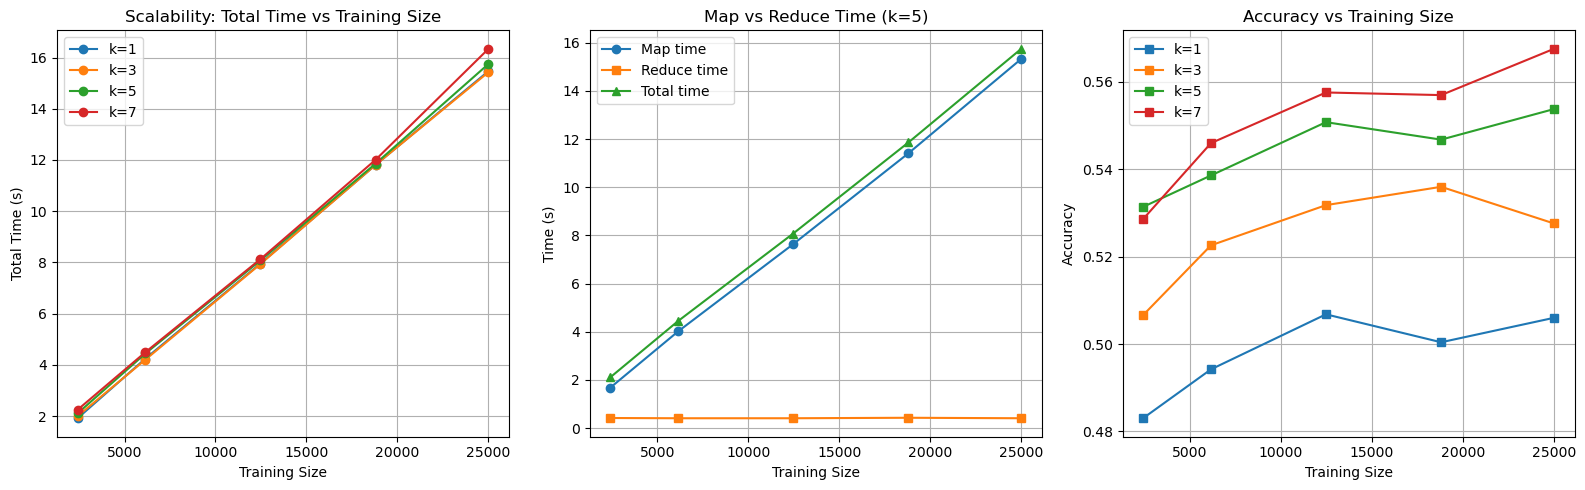

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Plot 1: Total time vs training size for each k
for k_val in K_VALUES:
    subset = scal_df[scal_df["k"] == k_val]
    axes[0].plot(subset["n_train"], subset["TotalTime(s)"],
                 marker='o', label=f"k={k_val}")
axes[0].set_xlabel("Training Size")
axes[0].set_ylabel("Total Time (s)")
axes[0].set_title("Scalability: Total Time vs Training Size")
axes[0].legend()
axes[0].grid(True)

# Plot 2: Map vs Reduce time breakdown (k=5)
k5 = scal_df[scal_df["k"] == 5]
axes[1].plot(k5["n_train"], k5["MapTime(s)"],    marker='o', label="Map time")
axes[1].plot(k5["n_train"], k5["RedTime(s)"],    marker='s', label="Reduce time")
axes[1].plot(k5["n_train"], k5["TotalTime(s)"],  marker='^', label="Total time")
axes[1].set_xlabel("Training Size")
axes[1].set_ylabel("Time (s)")
axes[1].set_title("Map vs Reduce Time (k=5)")
axes[1].legend()
axes[1].grid(True)

# Plot 3: Accuracy vs training size for each k
for k_val in K_VALUES:
    subset = scal_df[scal_df["k"] == k_val]
    axes[2].plot(subset["n_train"], subset["Accuracy"],
                 marker='s', label=f"k={k_val}")
axes[2].set_xlabel("Training Size")
axes[2].set_ylabel("Accuracy")
axes[2].set_title("Accuracy vs Training Size")
axes[2].legend()
axes[2].grid(True)

plt.tight_layout()
plt.savefig("k_frac_results.png", dpi=150)
plt.show()


In [19]:
# vary number of map tasks, fixed fraction=1.0, fixed test=5000
M_VALUES  = [16, 32, 64, 128]
FRACTION2 = 1.0

train_full_sample = train_full_rdd.sample(False, FRACTION2, seed=42)

part_results = []
total_runs2  = len(K_VALUES) * len(M_VALUES)
run2         = 0

for k_val in K_VALUES:
    for m in M_VALUES:
        run2 += 1
        print(f"[{run2}/{total_runs2}] k={k_val} | m={m}...")
        acc, map_t, red_t, glob_t = run_mrknn(
            train_full_sample, test_rdd, k_val, m, n_test_scal, ground_truth_scal
        )
        part_results.append({
            "k":          k_val,
            "# maps":     m,
            "MapTime(s)":   round(map_t,  2),
            "RedTime(s)":   round(red_t,  2),
            "TotalTime(s)": round(glob_t, 2),
            "Accuracy":     round(acc,    4),
        })
        print(f"  → MapT={map_t:.2f}s | RedT={red_t:.2f}s | Acc={acc:.4f}")

part_df = pd.DataFrame(part_results)
print(part_df.to_string(index=False))


# Save results
part_df.to_csv("k_m_results.csv", index=False)
print("\nSaved to k_m_results.csv")

[1/16] k=1 | m=16...


  → MapT=15.13s | RedT=0.26s | Acc=0.5060
[2/16] k=1 | m=32...


  → MapT=15.32s | RedT=0.48s | Acc=0.5072
[3/16] k=1 | m=64...


  → MapT=15.32s | RedT=0.85s | Acc=0.5036
[4/16] k=1 | m=128...


  → MapT=14.52s | RedT=1.64s | Acc=0.5054
[5/16] k=3 | m=16...


...

  → MapT=14.67s | RedT=2.85s | Acc=0.5540
[13/16] k=7 | m=16...


  → MapT=15.26s | RedT=0.49s | Acc=0.5676
[14/16] k=7 | m=32...


  → MapT=15.32s | RedT=1.06s | Acc=0.5670
[15/16] k=7 | m=64...


  → MapT=15.25s | RedT=1.85s | Acc=0.5698
[16/16] k=7 | m=128...


  → MapT=14.67s | RedT=3.59s | Acc=0.5678
 k  # maps  MapTime(s)  RedTime(s)  TotalTime(s)  Accuracy
 1      16       15.13        0.26         15.41    0.5060
 1      32       15.32        0.48         15.82    0.5072
 1      64       15.32        0.85         16.21    0.5036
 1     128       14.52        1.64         16.19    0.5054
 3      16       15.20        0.33         15.55    0.5276
 3      32       15.23        0.64         15.90    0.5342
 3      64       15.17        1.22         16.42    0.5330
 3     128       14.58        2.24         16.85    0.5326
 5      16       15.90        0.42         16.34    0.5538
 5      32       15.38        0.82         16.22    0.5572
 5      64       15.25        1.51         16.80    0.5502
 5     128       14.67        2.85         17.55    0.5540
 7      16       15.26        0.49         15.78    0.5676
 7      32       15.32        1.06         16.41    0.5670
 7      64       15.25        1.85         17.12    0.5698
 7     128    

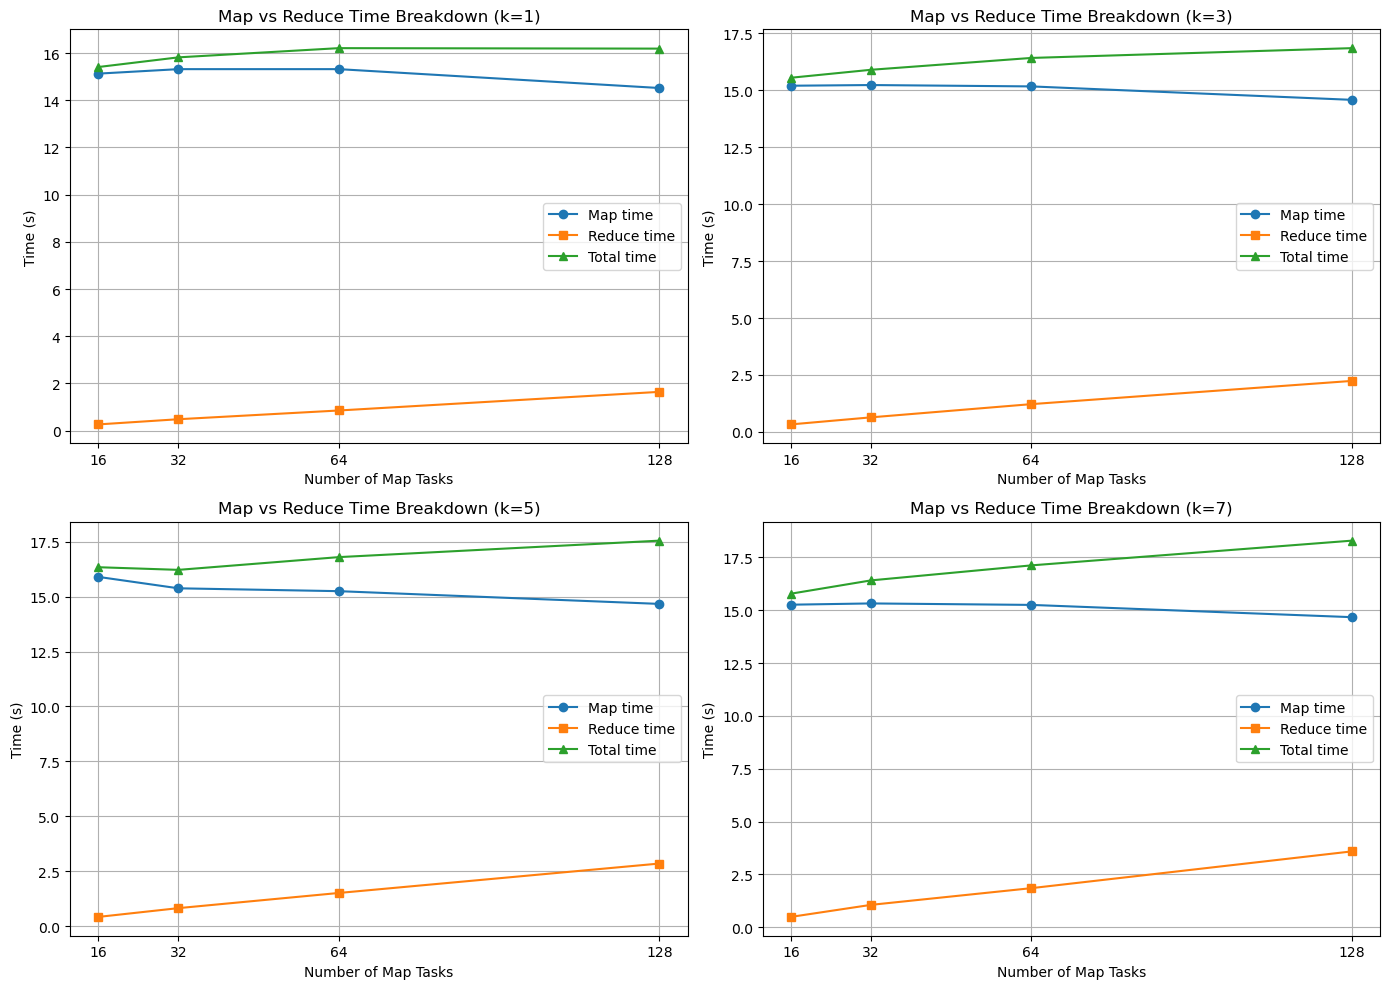

In [20]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for idx, k_val in enumerate(K_VALUES):
    subset = part_df[part_df["k"] == k_val]
    ax     = axes[idx]
    ax.plot(subset["# maps"], subset["MapTime(s)"],   marker='o', label="Map time")
    ax.plot(subset["# maps"], subset["RedTime(s)"],   marker='s', label="Reduce time")
    ax.plot(subset["# maps"], subset["TotalTime(s)"], marker='^', label="Total time")
    ax.set_xlabel("Number of Map Tasks")
    ax.set_ylabel("Time (s)")
    ax.set_title(f"Map vs Reduce Time Breakdown (k={k_val})")
    ax.set_xticks(subset["# maps"])
    ax.legend()
    ax.grid(True)

plt.tight_layout()
plt.savefig("mrknn_time_breakdown.png", dpi=150, bbox_inches='tight')
plt.show()
